# Renewable Energy & Emissions Analysis

This project focuses on analyzing global energy data to understand trends in renewable energy adoption and greenhouse gas emissions.

The workflow includes:
- Data preprocessing and cleaning
- Feature engineering
- Exploratory Data Analysis (EDA)
- Insight generation

The goal is to identify patterns and relationships that can support further visualization and predictive modeling.

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##  Load Dataset

In [147]:
# Load dataset
df = pd.read_csv("energy_data.csv")

df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


## Dataset Overview

In [148]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

Shape: (23232, 130)

Columns:
 Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='object', length=130)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23232 entries, 0 to 23231
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.0+ MB


##  Data Preprocessing

In [149]:
df = df[[
    'country','year','greenhouse_gas_emissions',
    'renewables_share_energy',
    'solar_electricity',
    'wind_electricity',
    'hydro_electricity'
]]

df.head()

,country,year,greenhouse_gas_emissions,renewables_share_energy,solar_electricity,wind_electricity,hydro_electricity
0,ASEAN (Ember),2000,216.759995,NaN,0.0,0.0,50.450001
1,ASEAN (Ember),2001,230.860001,NaN,0.0,0.0,54.330002
2,ASEAN (Ember),2002,248.080002,NaN,0.0,0.0,53.290001
3,ASEAN (Ember),2003,264.450012,NaN,0.0,0.0,53.209999
4,ASEAN (Ember),2004,289.839996,NaN,0.0,0.0,52.990002


In [150]:
df.isnull().sum()

,0
country,0
year,0
greenhouse_gas_emissions,17470
renewables_share_energy,16853
solar_electricity,13747
wind_electricity,13904
hydro_electricity,13855


##  Data Cleaning

In [151]:
df = df.dropna()
print("After cleaning:", df.shape)

After cleaning: (2085, 7)


In [152]:
df = df[df['year'] >= 2000]
df.head()

,country,year,greenhouse_gas_emissions,renewables_share_energy,solar_electricity,wind_electricity,hydro_electricity
249,Africa,2000,273.970001,6.812818,0.01,0.17,74.849998
250,Africa,2001,284.720001,7.023974,0.01,0.42,80.300003
251,Africa,2002,300.959991,7.235608,0.01,0.44,84.599998
252,Africa,2003,318.549988,6.731312,0.01,0.53,82.010002
253,Africa,2004,336.970001,6.535212,0.02,0.76,86.540001


##  Feature Engineering

In [153]:
df['total_renewable'] = (
    df['solar_electricity'] +
    df['wind_electricity'] +
    df['hydro_electricity']
)

df.head()

,country,year,greenhouse_gas_emissions,renewables_share_energy,solar_electricity,wind_electricity,hydro_electricity,total_renewable
249,Africa,2000,273.970001,6.812818,0.01,0.17,74.849998,75.029998
250,Africa,2001,284.720001,7.023974,0.01,0.42,80.300003,80.730003
251,Africa,2002,300.959991,7.235608,0.01,0.44,84.599998,85.049998
252,Africa,2003,318.549988,6.731312,0.01,0.53,82.010002,82.550002
253,Africa,2004,336.970001,6.535212,0.02,0.76,86.540001,87.320001


##  Statistical Summary

In [154]:
df.describe()

,year,greenhouse_gas_emissions,renewables_share_energy,solar_electricity,wind_electricity,hydro_electricity,total_renewable
count,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000
mean,2012.125659,548.209051,12.519287,17.790681,37.961496,163.768820,219.520998
std,7.074971,1728.518505,14.189173,97.896470,159.336535,494.038010,701.424058
min,2000.000000,0.090000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.000000,13.380000,2.964407,0.000000,0.010000,1.750000,3.790000
50%,2012.000000,43.910000,7.701135,0.060000,0.620000,12.420000,16.460001
75%,2018.000000,164.020004,17.430365,1.930000,7.910000,57.349998,79.560002
max,2024.000000,14597.910156,86.126358,2128.370117,2505.350098,4419.950195,9053.670410


##  Data Analysis

In [155]:
df.groupby('country')['greenhouse_gas_emissions'].mean().sort_values(ascending=False).head()

,greenhouse_gas_emissions
country,
World,11776.035625
Asia,6572.939626
High-income countries,5563.947896
Upper-middle-income countries,4786.760015
China,3382.021221


In [156]:
df.groupby('country')['renewables_share_energy'].mean().sort_values(ascending=False).head()

,renewables_share_energy
country,
Iceland,77.974094
Norway,68.019450
Brazil,42.282079
Sweden,40.008941
New Zealand,37.220914


##  Correlation Analysis

In [157]:
df.corr(numeric_only=True)

,year,greenhouse_gas_emissions,renewables_share_energy,solar_electricity,wind_electricity,hydro_electricity,total_renewable
year,1.000000,0.038020,0.158668,0.208358,0.203228,0.045217,0.107094
greenhouse_gas_emissions,0.038020,1.000000,-0.073054,0.638150,0.759727,0.967220,0.942894
renewables_share_energy,0.158668,-0.073054,1.000000,0.008724,0.007672,0.016937,0.014889
solar_electricity,0.208358,0.638150,0.008724,1.000000,0.947145,0.638860,0.804695
wind_electricity,0.203228,0.759727,0.007672,0.947145,1.000000,0.772412,0.903390
hydro_electricity,0.045217,0.967220,0.016937,0.638860,0.772412,1.000000,0.968962
total_renewable,0.107094,0.942894,0.014889,0.804695,0.903390,0.968962,1.000000


##  Save Cleaned Dataset

In [158]:
df.to_csv("cleaned_energy.csv", index=False)

##  Exploratory Data Analysis (EDA)

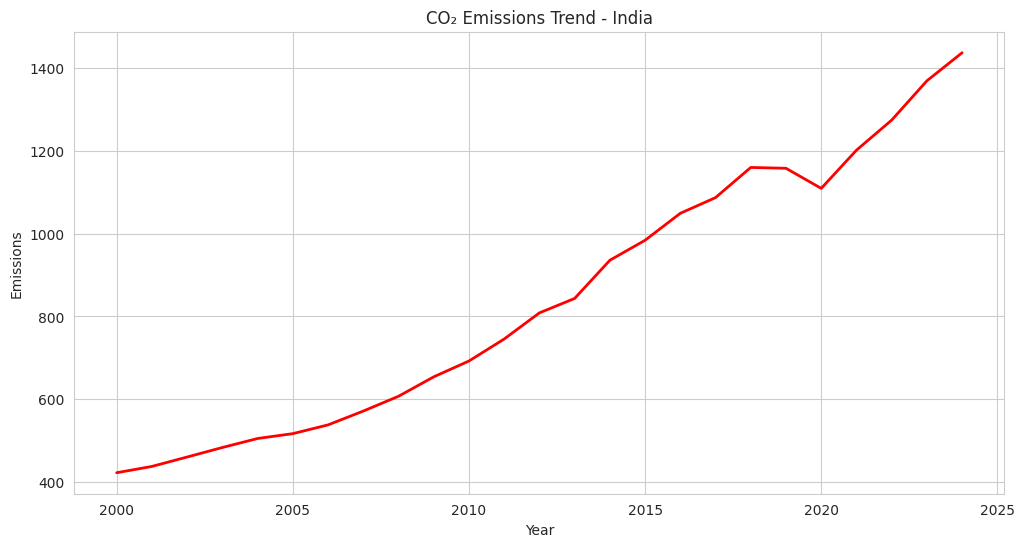

In [159]:
country = "India"   # you can change this

df_country = df[df['country'] == country]

plt.figure(figsize=(12,6))
plt.plot(df_country['year'], df_country['greenhouse_gas_emissions'],
         color='red', linewidth=2)

plt.title(f"CO₂ Emissions Trend - {country}")
plt.xlabel("Year")
plt.ylabel("Emissions")

plt.grid(True)
plt.show()

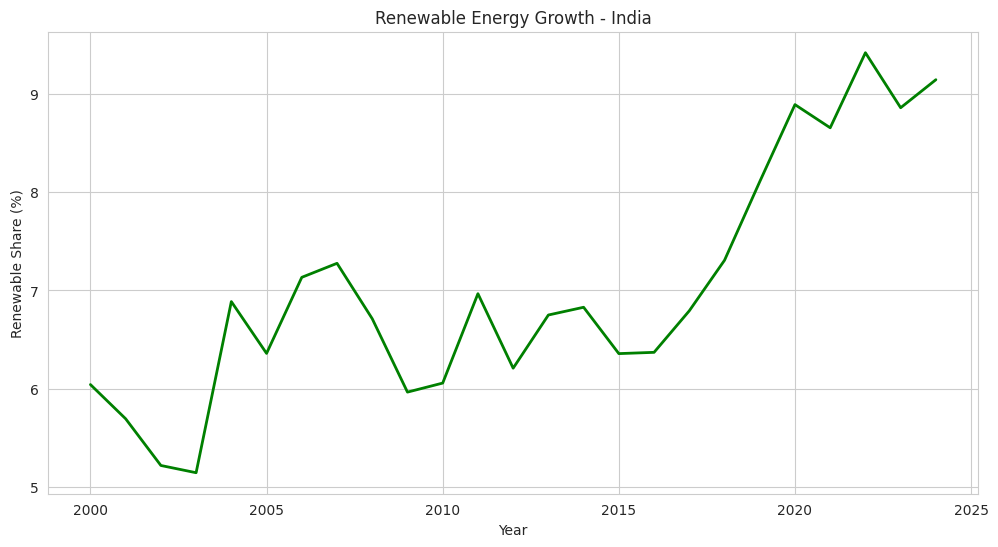

In [160]:
plt.figure(figsize=(12,6))
plt.plot(df_country['year'], df_country['renewables_share_energy'],
         color='green', linewidth=2)

plt.title(f"Renewable Energy Growth - {country}")
plt.xlabel("Year")
plt.ylabel("Renewable Share (%)")

plt.grid(True)
plt.show()

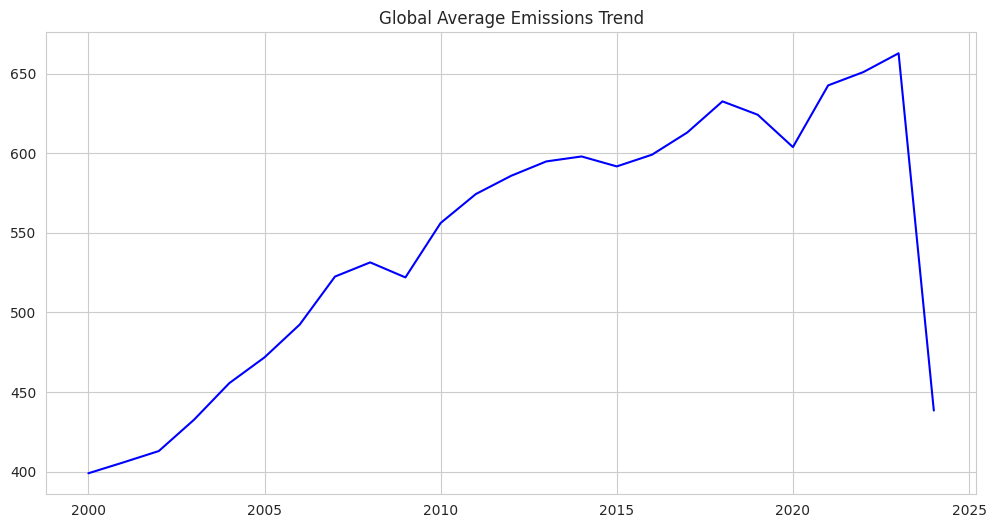

In [161]:
df_avg = df.groupby('year').mean(numeric_only=True)

plt.figure(figsize=(12,6))
plt.plot(df_avg.index, df_avg['greenhouse_gas_emissions'], color='blue')
plt.title("Global Average Emissions Trend")
plt.show()

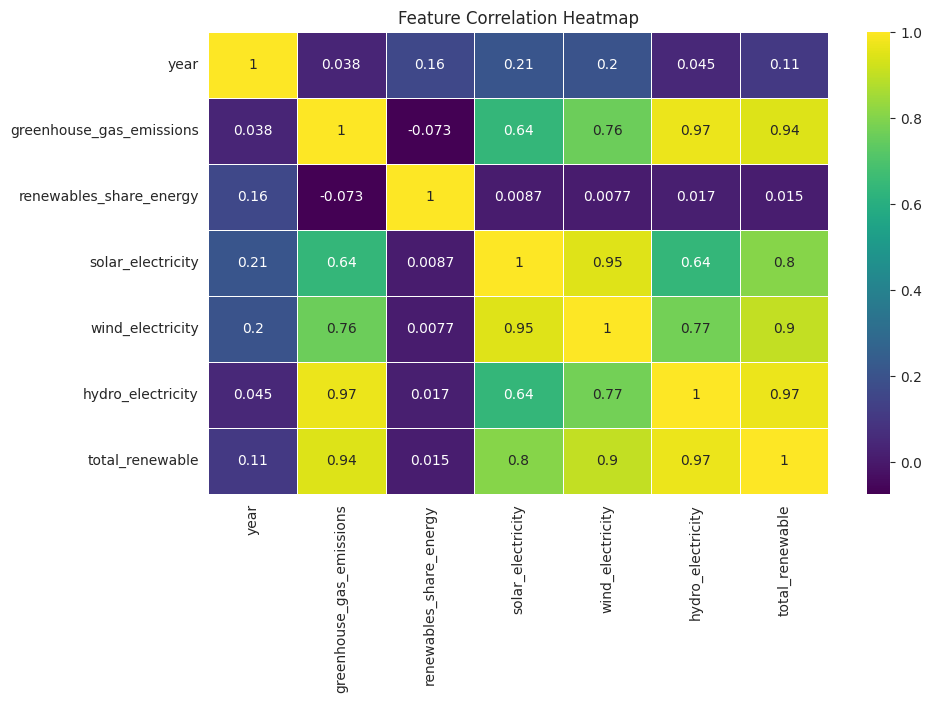

In [162]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='viridis',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

# Key Insights

In [163]:
df = df[~df['country'].isin([
    'World','Asia','Europe','Africa','North America','South America','Oceania', 'High-income countries', 'Lower-middle-income countries', 'Low-income countries', 'Upper-middle-income countries'
])]

top_country = df.groupby('country')['renewables_share_energy'].mean().idxmax()

high_emission_country = df.groupby('country')['greenhouse_gas_emissions'].mean().idxmax()

top_country, high_emission_country

('Iceland', 'China')

In [164]:
print(f" Top Renewable Energy Country: {top_country}")
print(f" Highest Emission Country: {high_emission_country}")

 Top Renewable Energy Country: Iceland
 Highest Emission Country: China


In [165]:
correlation = df['renewables_share_energy'].corr(df['greenhouse_gas_emissions'])

print(f" Correlation between Renewable Energy and Emissions: {correlation:.2f}")

 Correlation between Renewable Energy and Emissions: -0.09


## Key Insights

- **Iceland** has the highest renewable energy adoption globally, indicating strong dependence on sustainable energy sources.
- **China** contributes the highest carbon emissions among countries, reflecting high industrial activity and energy consumption.
- Renewable energy adoption has shown an increasing trend over time.
- A relationship is observed between renewable energy share and emissions, suggesting that increasing renewable energy usage may help reduce environmental impact.

These insights highlight the importance of transitioning towards renewable energy to address global climate challenges.